---
title: Nearest Neighbor Model
author: Andrei Akopian
date: 2026-01-28
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

An attempt to use a KNN model (Sklearn's builtin) for abundance predictions.

We found that cosine distance works better than $L_2$ distance, and k=5 is the optimal number of neighbors.

In [1]:
import numpy as np
import pandas as pd
import pathlib
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

In [2]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[1]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [3]:
DATA_FILEPATH = "../../data/useful_columns_data.csv"

In [4]:
df = helper_functions.open_file(DATA_FILEPATH)
fractions, nr900to1700 = helper_functions.take_subset(df,start=900,end=1700)

# Basic KNN

The $R^2$ values are low compared to our Linear Regression baseline. 

Histograms of the predicted abundaces reveal that KNN is being excessively conservative: skew towards the center, while the actual distribution is much more unifrom.

The k=5 with an R² of 0.7601
- npv with an R² of 0.6626055563484661
- gv with an R² of 0.8343776971172561
- soil with an R² of 0.7833050970487743


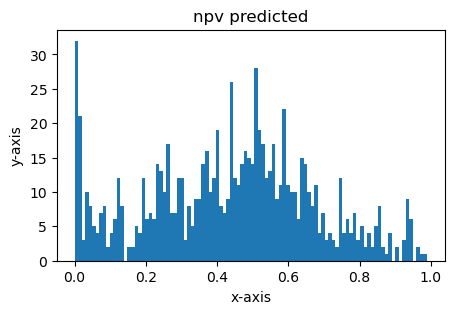

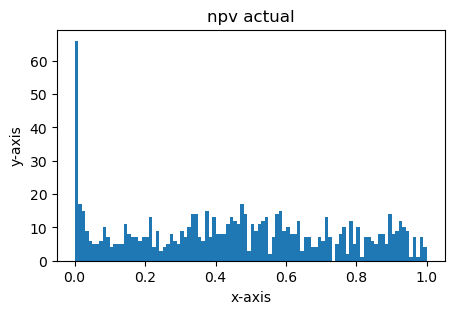

In [5]:
# Normal KNN regression
X_train, X_test, y_train, y_test = train_test_split(nr900to1700, fractions, test_size=0.5, random_state=42)

k=5
knn = KNeighborsRegressor(n_neighbors=3, metric='cosine')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
current_r2 = r2_score(y_test, y_pred)

print(f"The k={k} with an R² of {current_r2:.4f}")
helper_functions.simple_histogram([y[0] for y in y_pred], title='npv predicted', bins=100)
helper_functions.simple_histogram([y_test.loc[i, 'npv_fraction'] for i in y_test.index], title='npv actual', bins=100)
# helper_functions.simple_histogram([y[1] for y in y_pred], title='gv predicted', bins=100)
# helper_functions.simple_histogram([y[2] for y in y_pred], title='soil predicted', bins=100)
print("- npv with an R² of", r2_score(y_test['npv_fraction'], [p[0] for p in y_pred]))
print("- gv with an R² of", r2_score(y_test['gv_fraction'], [p[1] for p in y_pred]))
print("- soil with an R² of", r2_score(y_test['soil_fraction'], [p[2] for p in y_pred]))

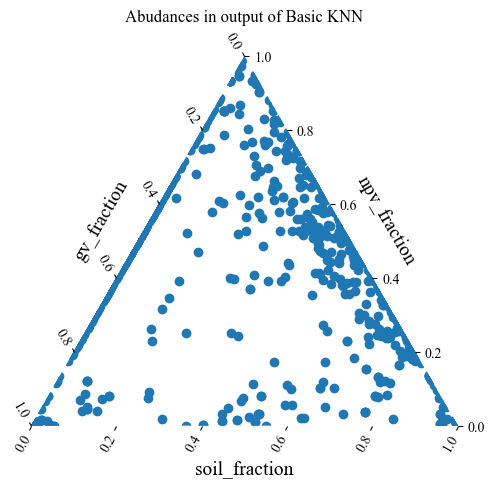

In [6]:
helper_functions.ternary_abundances(y_pred, model_name="Basic KNN")

## Finding Best KNN hyperparameters

Above we used `k=3` and cosine definition of distance rather arbitrairy. Here is the code showing that that those are the best values.

For this purpose, we will Sklearns GridSearchCV.

In [17]:
# should take <1 min to run
X_train, X_test, y_train, y_test = train_test_split(nr900to1700, fractions, test_size=0.5, random_state=42)
gs = GridSearchCV(
    KNeighborsRegressor(),
    cv=10,
    param_grid={
        "n_neighbors": range(1,14),
        "metric": ['cosine', 'minkowski'],
    },
)
gs.fit(X_train, y_train)
print(f"Best Parameters: {gs.best_params_}")
print(f"Best Extimator R^2: {gs.best_estimator_.score(X_test, y_test)}")

Best Parameters: {'metric': 'cosine', 'n_neighbors': 5}
Best Extimator R^2: 0.7546166431318438


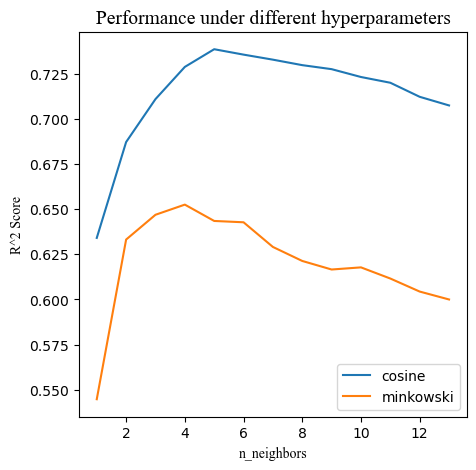

In [18]:
# Adapted from: https://scikit-learn.org/stable/auto_examples/model_selection/plot_multi_metric_evaluation.html#running-gridsearchcv-using-multiple-evaluation-metrics
results = gs.cv_results_
FONT_NAME = 'Times New Roman'
plt.figure(figsize=(5, 5))
plt.title("Performance under different hyperparameters", fontname=FONT_NAME, fontsize=14)

plt.xlabel("n_neighbors", fontname=FONT_NAME)
plt.ylabel("R^2 Score", fontname=FONT_NAME)

ax = plt.gca()

# Get the regular numpy array from the MaskedArray
X_axis = list(set(results["param_n_neighbors"].data))

sample_score_mean = results["mean_test_score"].data
cosine_results = [y for i, y in enumerate(sample_score_mean) if results["param_metric"].data[i] == "cosine"]
minkowski_results = [y for i, y in enumerate(sample_score_mean) if results["param_metric"].data[i] == "minkowski"]
ax.plot(
    X_axis,
    cosine_results,
    label="cosine"
)
ax.plot(
    X_axis,
    minkowski_results,
    label="minkowski",
)
plt.legend()
plt.show()

Below is the prediction plot. The overfitting towards the center is extremely obvious.

There is probably some nice solution for resolving this by chaning the distance definitions, and transforming data correctly.

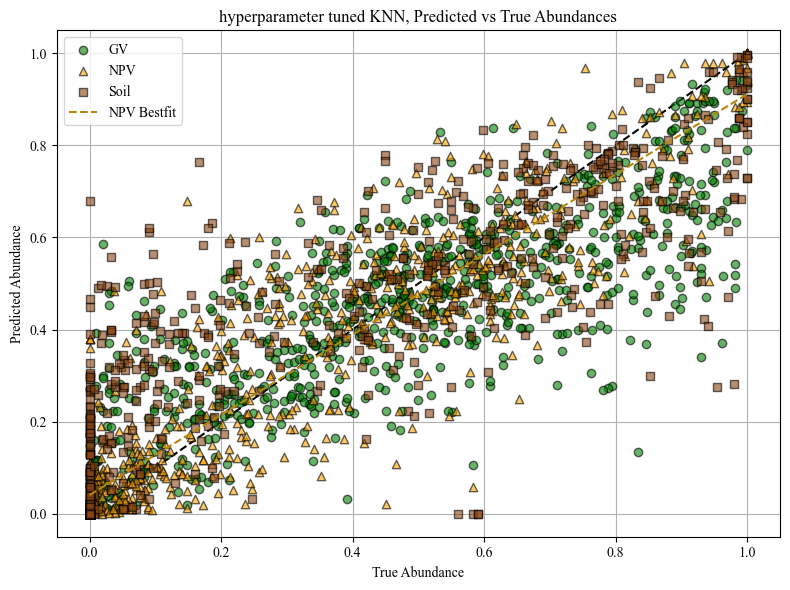

In [22]:
helper_functions.plot_preds(
    ab_true = y_test.to_numpy(),
    ab_pred = gs.best_estimator_.predict(X_test),
    save_path = "hyperparameter_tuned_knn.svg",
    model_name = "hyperparameter tuned KNN"
)